## 1. Objective
### Forecasting Google Trends Using VAR and SARIMA Models
- Introduction: 
This project analyzes the relationship between Bitcoin search interest and the term "Crypto Crash" using Google Trends data. 

- The goal is to understand whether changes in one search trend can help predict movements in the other, so this project applies time series forecasting techniques such as VAR and SARIMA models.

The Project includes: 
- collect and analyze Google Trends data using the pytrends library.
- checking stationarity and integration order of the time series.
- performing Granger causality tests.
- building VAR and SARIMA forecasting models.
- generating out-of-sample forecasts.
- comparing model performance using RMSE and MAE metrics.

- The results will help determine whether multivariate (VAR) or univariate (SARIMA) models better capture and predict Google search behavior in the cryptocurrency market.

### Import Libraries

In [26]:
!pip install pytrends

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pytrends.request import TrendReq
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\getde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Data Collection

In [27]:
from pytrends.request import TrendReq

pytrends = TrendReq()

kw_list = ["Bitcoin", "Crypto crash"]

pytrends.build_payload(kw_list,
                       timeframe='2021-01-01 2026-01-01',
                       geo='')

data = pytrends.interest_over_time()
data = data.drop(columns=['isPartial'])

# Save CSV 
data.to_csv("bitcoin_crypto_trends.csv", index=True)

data.head()

,Bitcoin,Crypto crash
date,,
2020-12-27,54,0
2021-01-03,85,0
2021-01-10,84,0
2021-01-17,52,0
2021-01-24,49,0


## 3. Data Interpretation
- The dataset was obtained from Google Trends using the Pytrends library and includes weekly search interest for the keywords "Bitcoin" and "Crypto crash" from 2021 to 2026.
- The Bitcoin series shows continuous fluctuations over time, reflecting changing public interest in cryptocurrency markets.
- The Crypto crash series contains mostly low values with occasional sharp spikes, indicating that search activity increases mainly during periods of market stress or major crypto-related events.
- Overall, the data suggests that Bitcoin attracts consistent attention, while searches for Crypto crash are largely event-driven.

In [28]:
print(data.index[:10])
print(data.index.to_series().diff().value_counts())

DatetimeIndex(['2020-12-27', '2021-01-03', '2021-01-10', '2021-01-17',
               '2021-01-24', '2021-01-31', '2021-02-07', '2021-02-14',
               '2021-02-21', '2021-02-28'],
              dtype='datetime64[ns]', name='date', freq=None)
date
7 days    261
Name: count, dtype: int64


## 4. Initial Inspection

In [29]:
data = pd.read_csv("bitcoin_crypto_trends.csv", index_col=0, parse_dates=True)
data.head()


,Bitcoin,Crypto crash
date,,
2020-12-27,54,0
2021-01-03,85,0
2021-01-10,84,0
2021-01-17,52,0
2021-01-24,49,0


### Data Loading and Initial Inspection
The dataset was successfully loaded from the saved CSV file. The preview confirms that both variables are present and correctly indexed by date. This ensures the data is ready for further analysis.

## 5. Stationary Test (Augmented Dickey-Fuller Test)

In [30]:
from statsmodels.tsa.stattools import adfuller

for col in data.columns:
    result = adfuller(data[col])
    print(f"Results for {col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------")

Results for Bitcoin
ADF Statistic: -3.3362861330466127
p-value: 0.013332374878714113
----------------------
Results for Crypto crash
ADF Statistic: -6.0025995800449214
p-value: 1.643783188431306e-07
----------------------


### Stationarity Test (Augmented Dickey-Fuller Test):

#### Hypothesis:
- null hypothesis (H₀): The time series is non-stationary (has a unit root).
- Alternative hypothesis (H₁): The time series is stationary.

#### 5.1 Result and Interpretation:
- The Augmented Dickey-Fuller (ADF) test results indicate that both “Bitcoin” and “Crypto crash” series are stationary, as their p-values are below the 0.05 significance level.
- In particular, the p-value for “crypto crash” is extremely close to zero, which provides strong statistical evidence against the presence of a unit root. This confirms that the series is highly stationary.
- Therefore, the null hypothesis of non-stationarity is rejected for both variables, and the original series can be directly used for further analysis without applying differencing.

## 6. Verification

In [31]:
print(data.columns)

Index(['Bitcoin', 'Crypto crash'], dtype='object')


In [32]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2020-12-27 to 2025-12-28
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Bitcoin       262 non-null    int64
 1   Crypto crash  262 non-null    int64
dtypes: int64(2)
memory usage: 6.1 KB
None


### Data Structure Verification
- The dataset contains 262 weekly observations from December 2020 to December 2025.
- Both variables, Bitcoin and Crypto Crash have complete data with no missing values.
- The date column is correctly set as a Date Time Index making the dataset suitable for time series.
- The data structure and variable types are appropriate for further statistical testing and forecasting.

## 7. Granger Causality Test
### Hypotheses
**Test 1: Bitcoin → Crypto crash**
- H₀: The first variable does NOT Granger-cause the second variable.
- H₁: The first variable DOES Granger-cause the second variable.

**Test 2: Crypto crash → Bitcoin**
- H₀: “crypto crash” does not Granger-cause Bitcoin
- H₁: “crypto crash” Granger-causes Bitcoin


In [33]:
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(data[['Bitcoin', 'Crypto crash']], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.9176  , p=0.0157  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=5.9865  , p=0.0144  , df=1
likelihood ratio test: chi2=5.9188  , p=0.0150  , df=1
parameter F test:         F=5.9176  , p=0.0157  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.7368  , p=0.0251  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=7.6202  , p=0.0221  , df=2
likelihood ratio test: chi2=7.5107  , p=0.0234  , df=2
parameter F test:         F=3.7368  , p=0.0251  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6217  , p=0.1848  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=5.0004  , p=0.1718  , df=3
likelihood ratio test: chi2=4.9527  , p=0.1753  , df=3
parameter F test:         F=1.6217  , p=0.1848  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.2493  , p=0.0127  

{np.int64(1): ({'ssr_ftest': (np.float64(5.917645700710505),
    np.float64(0.015670330645853464),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.986455534439697),
    np.float64(0.014416141446923917),
    np.int64(1)),
   'lrtest': (np.float64(5.918833099859057),
    np.float64(0.014979876448306801),
    np.int64(1)),
   'params_ftest': (np.float64(5.917645700710605),
    np.float64(0.01567033064585308),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.7368291318226325),
    np.float64(0.025144508613241613),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(7.62020058254027),
    np.float64(0.02214595779942176),
    np.int64(2)),
   'lrtest': (np.float64(7.510667415180478),
    np.float64(0.023392643004028758),
    np.int64(2)),
   'params_ftest': (np.float64(3.7368291318226277),
    np.float64(0.025144508613242505),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

### 7.1 Interpretation of Granger Causality Test:
#### Test 1:
- The Granger Causality Test was conducted to determine whether Bitcoin can predict Crypto Crash events.
- The null hypothesis states that Bitcoin does not Granger-cause Crypto Crash. 
- The results indicate statistically significant causality at lag lengths 1, 2, 4, and 5, the p-values obtained from the SSR-based F-test, Chi-square test, Likelihood Ratio test, and Parameter F-test are all below the 5% significance level. Therefore, the null hypothesis is rejected for these lags. This indicates that past Bitcoin values contain statistically significant information that helps predict future Crypto Crash movements.
- However, for lag 3, the p-values exceed 0.05, so the null hypothesis cannot be rejected at that lag. Overall, the evidence suggests the existence of Granger causality from Bitcoin to Crypto Crash, particularly at lag lengths 1, 2, 4, and 5.

### 7.2 Reverse Causality 

In [34]:
grangercausalitytests(data[['Crypto crash', 'Bitcoin']], maxlag=5)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0461  , p=0.8301  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=0.0467  , p=0.8290  , df=1
likelihood ratio test: chi2=0.0467  , p=0.8290  , df=1
parameter F test:         F=0.0461  , p=0.8301  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0242  , p=0.9761  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=0.0494  , p=0.9756  , df=2
likelihood ratio test: chi2=0.0494  , p=0.9756  , df=2
parameter F test:         F=0.0242  , p=0.9761  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0481  , p=0.9860  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=0.1482  , p=0.9855  , df=3
likelihood ratio test: chi2=0.1482  , p=0.9855  , df=3
parameter F test:         F=0.0481  , p=0.9860  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.8318  , p=0.5060  

{np.int64(1): ({'ssr_ftest': (np.float64(0.04611810146982067),
    np.float64(0.8301309051610747),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.046654358463655794),
    np.float64(0.8289907095276479),
    np.int64(1)),
   'lrtest': (np.float64(0.04665018917262387),
    np.float64(0.8289982327770093),
    np.int64(1)),
   'params_ftest': (np.float64(0.04611810146970117),
    np.float64(0.8301309051612825),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.02422838170043301),
    np.float64(0.9760650160577395),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.04940689601656928),
    np.float64(0.9755991850154047),
    np.int64(2)),
   'lrtest': (np.float64(0.04940220230128034),
    np.float64(0.9756014746104966),
    np.int64(2)),
   'params_ftest': (np.float64(0.02422838170047666),
    np.float64(0.9760650160576981),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.

### 7.3 Interpretation of Reverse Causality Test
- A reverse Granger Causality Test was conducted to examine whether Crypto Crash events can predict Bitcoin movements.
-  The null hypothesis states that Crypto Crash does not Granger-cause Bitcoin. The results show that the p-values for all lag lengths (1–5) are greater than the 5% significance level.
- Therefore, the null hypothesis cannot be rejected. This indicates that past Crypto Crash values do not provide statistically significant information for predicting future Bitcoin movements.
- There is no evidence of Granger causality running from Crypto Crash to Bitcoin.

## 8. VAR Model Specification and Lag Selection

In [35]:
from statsmodels.tsa.api import VAR

model = VAR(data)

lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.8766      0.9046       2.403      0.8879
1      -0.2316    -0.1476*      0.7932    -0.1978*
2      -0.2161    -0.07602      0.8057     -0.1597
3      -0.1923    0.003791      0.8251     -0.1134
4      -0.2108     0.04130      0.8100     -0.1094
5     -0.2632*     0.04494     0.7687*     -0.1392
6      -0.2556      0.1085      0.7746     -0.1091
7      -0.2566      0.1636      0.7739    -0.08750
8      -0.2288      0.2474      0.7958    -0.03720
9      -0.2007      0.3315      0.8187     0.01348
10     -0.1868      0.4015      0.8303     0.04991
--------------------------------------------------


c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Interpretation of VAR and Lag Selection
- To determine the optimal number of lags for the VAR model, several information criteria were used, including the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), Final Prediction Error (FPE), and Hannan-Quinn Information Criterion (HQIC).
- The results indicate that AIC and FPE suggest using 5 lags, while BIC and HQIC point to a shorter lag length of 1. Since AIC is generally preferred in time series analysis for its ability to capture more detailed dynamic relationships, the model with 5 lags was chosen for further analysis.
- Moreover, selecting 5 lags is consistent with earlier Granger causality results, where stronger and more significant relationships were observed at higher lag values.

## 9.VAR Model Estimation

In [36]:
var_model = model.fit(5)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 05, Sep, 2026
Time:                     23:25:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   0.166631
Nobs:                     257.000    HQIC:                -0.0150032
Log likelihood:          -689.707    FPE:                   0.871903
AIC:                    -0.137181    Det(Omega_mle):        0.801798
--------------------------------------------------------------------
Results for equation Bitcoin
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   3.746891         1.331539            2.814           0.005
L1.Bitcoin              0.721523         0.071119           10.145           0.000
L1.Crypto crash        -5.949145         4.009323 

### Interpretation of VAR Model Estimation
- The VAR model with 5 lags was used to study the relationship between Bitcoin and “crypto crash” searches.
- The results show that Bitcoin is mainly influenced by its own past values, indicating a strong persistence over time. In addition, “crypto crash” has a noticeable impact on Bitcoin, but only at certain lags, suggesting that this effect appears with some delay.
- Overall, Bitcoin behavior is mostly driven by its own trend, with some delayed influence from panic-related searches.

### Importance of Stationarity in VAR Modeling
- Stationarity is required for VAR modeling because it ensures stable properties over time.
- The ADF test results indicated that both series are stationary allowing the VAR model to be estimated without additional transformation.

### Importance of Granger Causality Test in VAR Modeling
- The Granger Causality test helps determine whether past values of one variable improve the prediction of another.
- The result indicate that Bitcoin search interest Granger-causes Crypto Crash searchs, suggesting that changes in Bitcoin related searches may precede changes in panic related search.
- No evidence was found that Crypto Crash searches Granger-cause Bitcoin searches, indicating a one-way predictive relationship.

### Fitted vs Actual Values
- The fitted values follow the actual data reasonably well, indicating that the VAR model is able to capture the main patterns in both series. Some differences remain, especially during sudden spikes, which is expected in volatile search data.

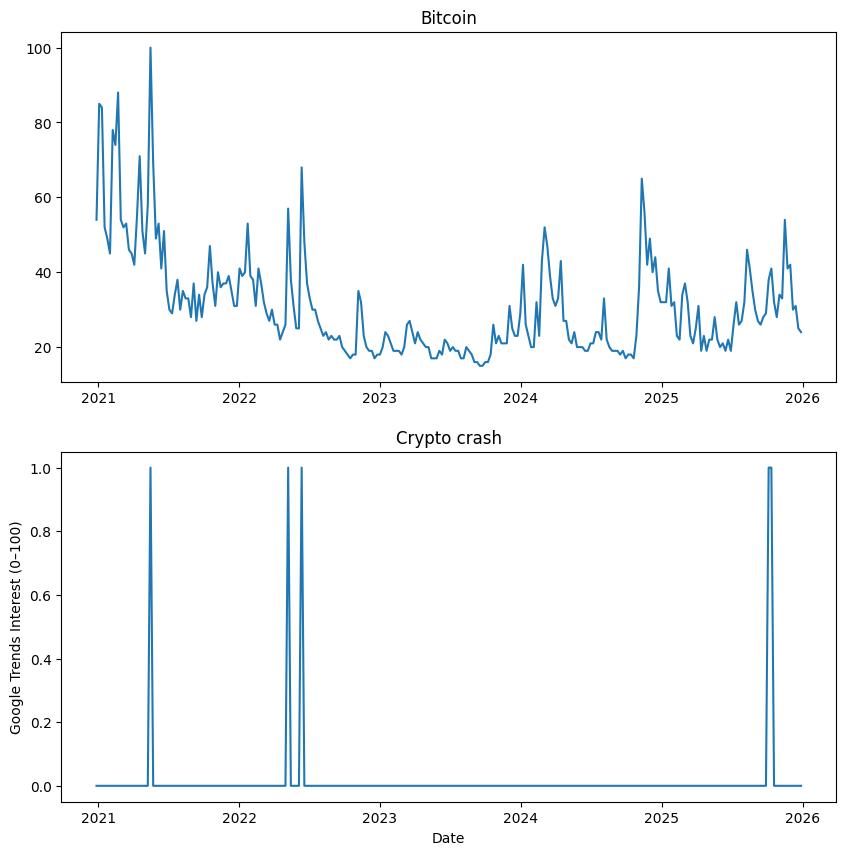

In [38]:
import matplotlib.pyplot as plt

var_model.plot()
plt.xlabel("Date")
plt.ylabel("Google Trends Interest (0–100)")
plt.show()

### Interpretation of Bitcoin and Crypto Crash Trends
- The Bitcoin series shows noticeable fluctuations throughout the period, reflecting changing levels of public interest in cryptocurrency market. Search activity was high in the early years, followed by a relatively stable period and renewed fluctuations towards the end of the sample.
- On the other side, the Crypto Crash series remains at low levels for most of the period, with only a few sharp spikes. These spikes correspond to periods of heightened concern or market stress and indicate that crash-related searches are largely event-driven.
- Overall, the data suggests that interest in Bitcoin is continuous and evolves over time, while interest in Crypto Crash emerges mainly during significant market disruptions. This highlights the difference between general market attention and panic driven search behavior.

## 10. Residual Plots

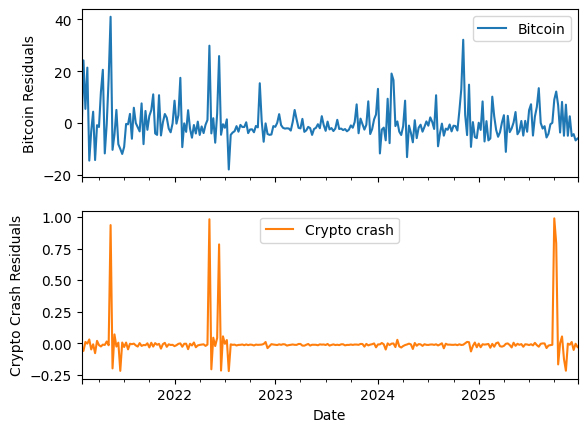

In [39]:
residuals = var_model.resid
axes = residuals.plot(subplots=True)

axes[0].set_ylabel("Bitcoin Residuals")
axes[1].set_ylabel("Crypto Crash Residuals")
axes[1].set_xlabel("Date")

plt.show()

### Residual Analysis
- The residual plots for both Bitcoin and “crypto crash” fluctuate around zero without showing any clear pattern or trend. This indicates that the model has successfully captured the underlying structure of the data.
- Although some spikes are present, especially in the “crypto crash” series, they are isolated and do not form any systematic pattern. This is expected given the nature of sudden panic-related searches.
- Overall, the residuals appear to behave like white noise, suggesting that the VAR model is well specified and provides a good fit to the data.

### 10.1 ACF and PACF of Residuals

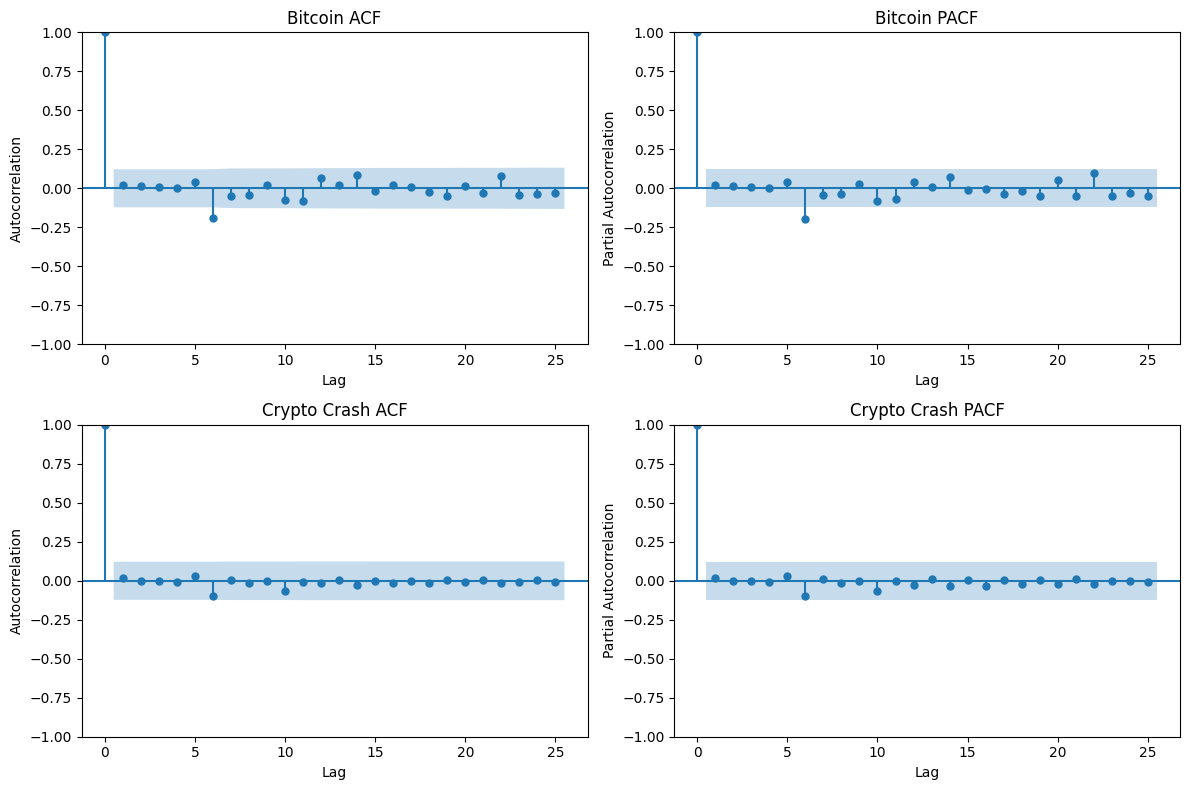

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Bitcoin ACF
plot_acf(residuals['Bitcoin'], ax=ax[0,0])
ax[0,0].set_title('Bitcoin ACF')
ax[0,0].set_xlabel('Lag')
ax[0,0].set_ylabel('Autocorrelation')

# Bitcoin PACF
plot_pacf(residuals['Bitcoin'], ax=ax[0,1])
ax[0,1].set_title('Bitcoin PACF')
ax[0,1].set_xlabel('Lag')
ax[0,1].set_ylabel('Partial Autocorrelation')

# Crypto Crash ACF
plot_acf(residuals['Crypto crash'], ax=ax[1,0])
ax[1,0].set_title('Crypto Crash ACF')
ax[1,0].set_xlabel('Lag')
ax[1,0].set_ylabel('Autocorrelation')

# Crypto Crash PACF
plot_pacf(residuals['Crypto crash'], ax=ax[1,1])
ax[1,1].set_title('Crypto Crash PACF')
ax[1,1].set_xlabel('Lag')
ax[1,1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

### Interpretation of ACF and PACF of Residuals
- The ACF and PACF plots for both Bitcoin and “crypto crash” residuals show that most autocorrelation values lie within the confidence bounds. This indicates that there is no significant autocorrelation remaining in the residuals.
- In simple terms, the residuals behave like white noise, meaning that the model has successfully captured the underlying patterns in the data.
-This confirms that the VAR model is well specified and provides a reliable representation of the relationship between the variables.

### 10.2 Residual Autocorrelation Test
- To check whether the residuals are free from autocorrelation, the Ljung-Box test was applied. The results indicate that there is no significant autocorrelation in the residuals.
- This suggests that the VAR model adequately captures the dynamic relationships between the variables and is correctly specified.

In [41]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Bitcoin residuals
acorr_ljungbox(residuals['Bitcoin'], lags=[10], return_df=True)

# Crypto crash residuals
acorr_ljungbox(residuals['Crypto crash'], lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,3.930527,0.950427


### Interpretation of Residual Autocorrelation Test
- The Ljung-Box test was applied to examine whether the residuals exhibit autocorrelation. The results show a high p-value (0.94), which is well above the 5% significance level. 
- This indicates that there is no significant autocorrelation in the residuals, meaning that the errors behave like white noise. Therefore, the VAR model is well specified and effectively captures the dynamics between Bitcoin and “crypto crash”.

### 10.3 Alternative VAR Specification
- Before finalizing the VAR model, it is important to test alternative model specifications with different lag lengths and we can observe that the selected model is not only statistically optimal but also robust.
- Different lag structures may capture the dynamics between variables more effectively, so comparing multiple VAR models allows us to identify the best-performing specification.
- The final choice is made based on information criteria such as AIC, which balances model fit and complexity.
- so, several VAR models with different lag lengths were estimated and compared in order to confirm that the selected VAR(5) model is appropriate.

In [42]:
from statsmodels.tsa.api import VAR

model = VAR(data)

# Fit models with different lags
var_1 = model.fit(1)
var_2 = model.fit(2)
var_3 = model.fit(3)
var_4 = model.fit(4)
var_5 = model.fit(5)

# Compare using AIC
print("Lag 1 AIC:", var_1.aic)
print("Lag 2 AIC:", var_2.aic)
print("Lag 3 AIC:", var_3.aic)
print("Lag 4 AIC:", var_4.aic)
print("Lag 5 AIC:", var_5.aic)


Lag 1 AIC: 0.04426590228001409
Lag 2 AIC: -0.024129192285820167
Lag 3 AIC: -0.001022232889367869
Lag 4 AIC: -0.1018547324761532
Lag 5 AIC: -0.13718132790544973


c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Interpretation of Alternative VAR Models Result:
- Different VAR models with lag lengths ranging from 1 to 5 were estimated and compared using the Akaike Information Criterion (AIC).
- The results show that the VAR model with 5 lags has the lowest AIC value (-0.1351), indicating the best balance between model fit and complexity.
- Therefore, the VAR(5) model is confirmed as the most appropriate specification for further analysis.

## 11. Impulse Response Function:
- The impulse response function is used to analyze how a shock (or sudden change) in one variable affects another variable over time within the VAR model.
- In this context, IRF helps us understand how shocks to Bitcoin influence “crypto crash” searches, and vice versa. It allows us to observe both the direction and duration of these effects.
- By examining the response over several periods, we can identify whether the impact is temporary or persistent, and whether it reinforces or dampens the relationship between the variables.

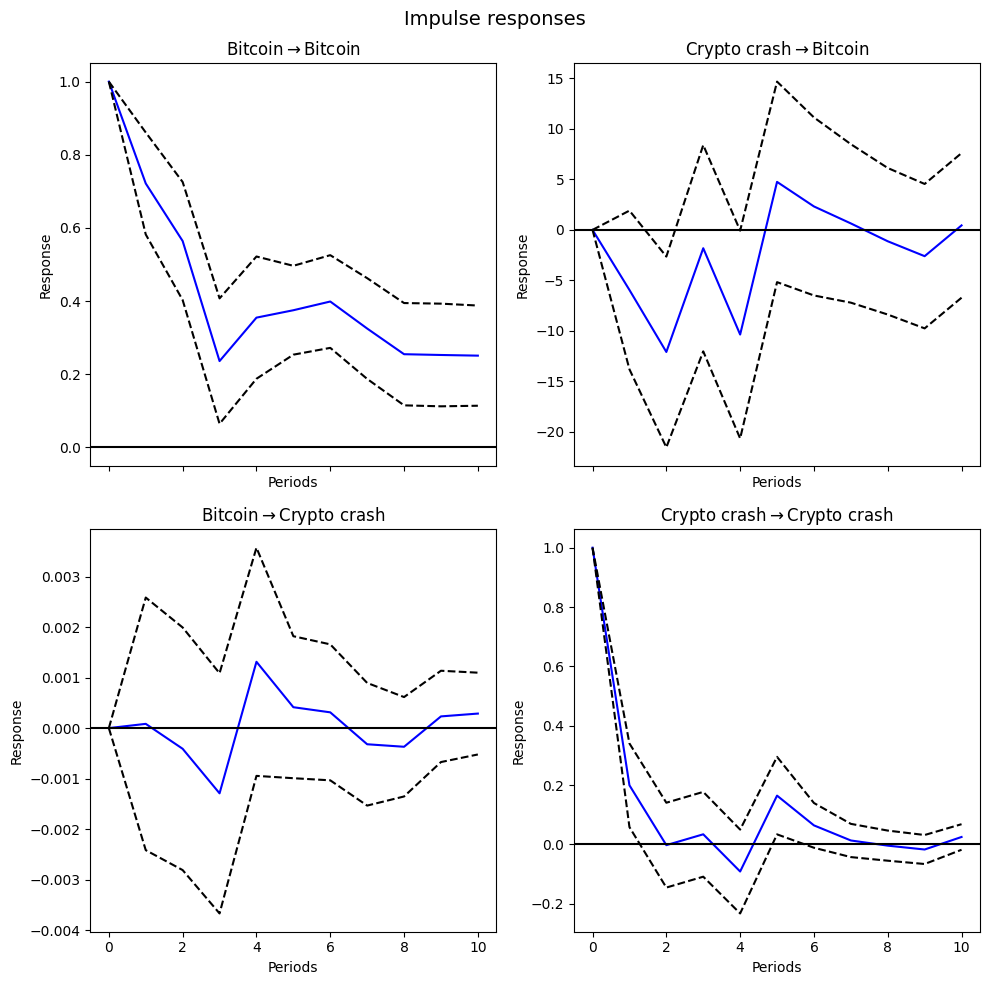

In [43]:
import matplotlib.pyplot as plt

irf = var_model.irf(10)

fig = irf.plot()

# Add axis labels to all IRF plots
for ax in fig.axes:
    ax.set_xlabel("Periods")
    ax.set_ylabel("Response")

plt.tight_layout()
plt.show()

### Interpretation of IRF
- As we can see that Bitcoin exhibits strong persistence, as shocks to Bitcoin have a large and gradually declining effect on itself. This means that Bitcoin dynamics are largely driven by its own past behavior.
- A Shock to Bitcoin also has noticeable positive effect on "Crypto Crash" searches in subsequent periods. This suggests that changes in Bitcoin activity can trigger increase in panic-related searches, although the impact is relatively weak and short-lived.
- In contrast, shocks to “crypto crash” have a limited and unstable effect on Bitcoin. The response fluctuates across periods and quickly fades, indicating that panic-related searches do not have strong predictive power for Bitcoin.
- Shocks to “crypto crash” itself show a sharp but short-lived response, reflecting the temporary nature of panic-driven search behavior.
- Overall, the results confirm that Bitcoin is the dominant variable in the system, driving the dynamics, while “crypto crash” plays a more reactive and short-term role. These findings are consistent with the earlier Granger causality results.

## 12. Forecast Error Variance Decomposition:
Forecast Error Variance Decomposition (FEVD) is used to understand how much of the variation in each variable is explained by its own shocks and by shocks to other variables in the system.

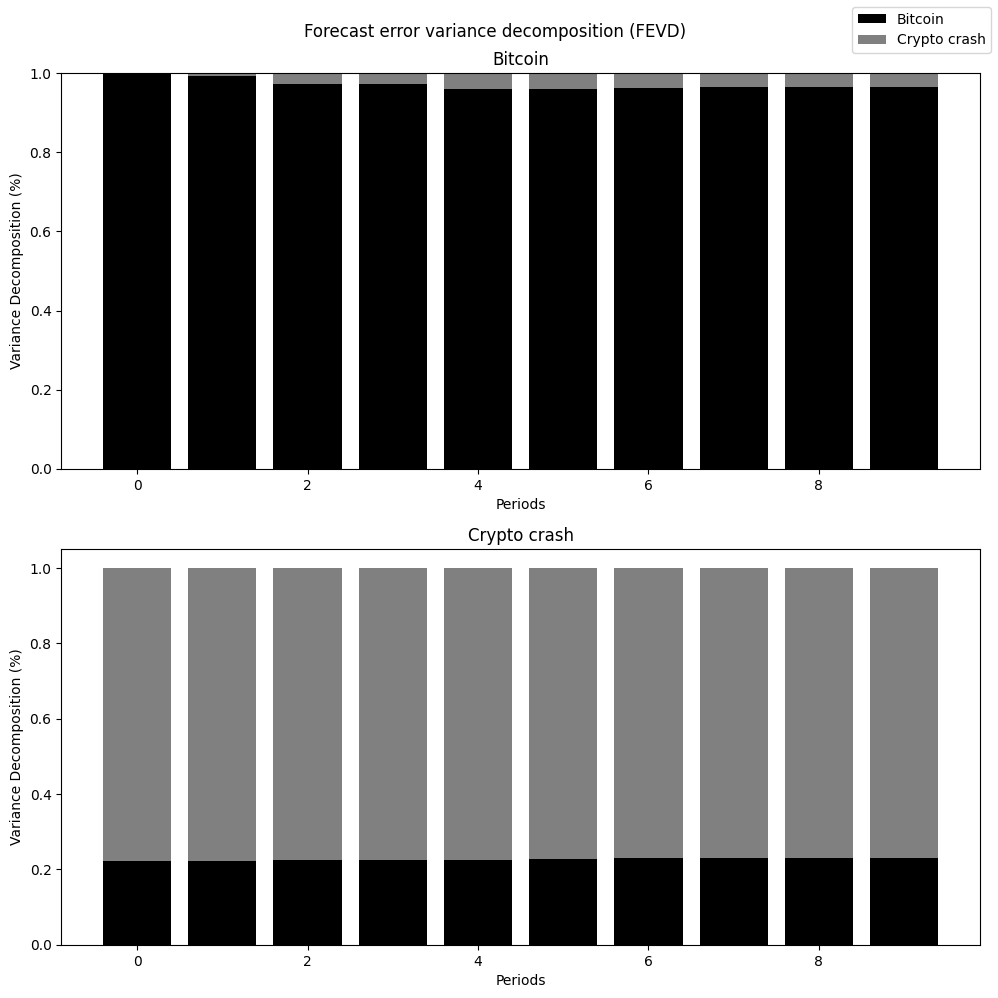

FEVD for Bitcoin
      Bitcoin  Crypto crash
0    1.000000      0.000000
1    0.993934      0.006066
2    0.973428      0.026572
3    0.973707      0.026293
4    0.960625      0.039375
5    0.961292      0.038708
6    0.963771      0.036229
7    0.965432      0.034568
8    0.966176      0.033824
9    0.966242      0.033758

FEVD for Crypto crash
      Bitcoin  Crypto crash
0    0.222832      0.777168
1    0.223505      0.776495
2    0.223937      0.776063
3    0.226073      0.773927
4    0.225335      0.774665
5    0.228208      0.771792
6    0.229146      0.770854
7    0.229214      0.770786
8    0.229574      0.770426
9    0.229541      0.770459


None


In [44]:
import matplotlib.pyplot as plt

fevd = var_model.fevd(10)

fig = fevd.plot()

# Add axis labels to all FEVD plots
for ax in fig.axes:
    ax.set_xlabel("Periods")
    ax.set_ylabel("Variance Decomposition (%)")

plt.tight_layout()
plt.show()

print(fevd.summary())

### Interpretation of Forecast Error Variance Decomposition Result:
- For Bitcoin, the results show that almost all of its variation (approximately 96%–100%) is explained by its own shocks across all periods. The contribution of “crypto crash” remains very small (around 3%–4%), indicating that Bitcoin is largely driven by its own dynamics.
- The variation in “crypto crash” is mainly explained by its own shocks (around 77%), but a notable portion (approximately 22%–23%) is explained by shocks to Bitcoin. This suggests that Bitcoin plays a significant role in influencing panic-related search behavior.
- Overall, these results indicate an asymmetric relationship, where Bitcoin acts as the dominant variable, while “crypto crash” is partially influenced by Bitcoin. This finding is consistent with the results obtained from the Granger causality test and impulse response analysis.

## 13. VAR Forecasting
- After estimating and validating the VAR model, forecasting is performed to predict future values of both Bitcoin and “crypto crash” based on historical data.
- The VAR model uses the relationships between the variables to generate forecasts over a specified horizon. This allows us to evaluate how well the model captures the dynamics of the system and to analyze future trends.
- These forecasts will later be compared with actual values in the out-of-sample period to assess the accuracy of the model.

### 13.1 Split Data (Train/Test)

In [20]:
# Split data
train = data[:-20]
test = data[-20:]

### 13.2 Fit Model again (on TRAIN data)

In [21]:
from statsmodels.tsa.api import VAR

model = VAR(train)
var_model = model.fit(5)  # using chosen lag

c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### 13.3 VAR Forecast

In [22]:
forecast_input = train.values[-var_model.k_ar:]

forecast = var_model.forecast(forecast_input, steps=20)

# Convert to DataFrame
import pandas as pd

forecast_df = pd.DataFrame(forecast, index=test.index, columns=data.columns)

### 13.4 Plot Forecast vs Actual

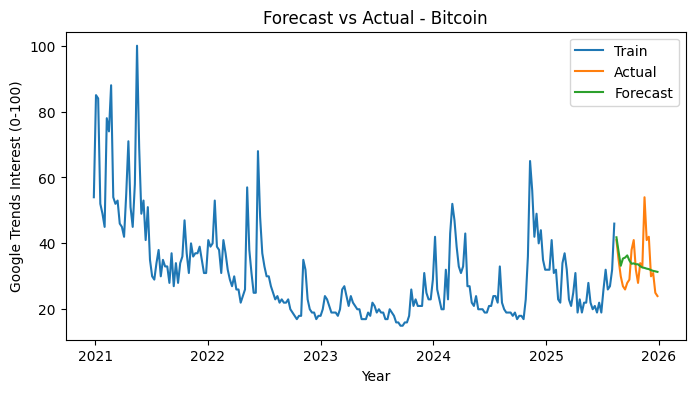

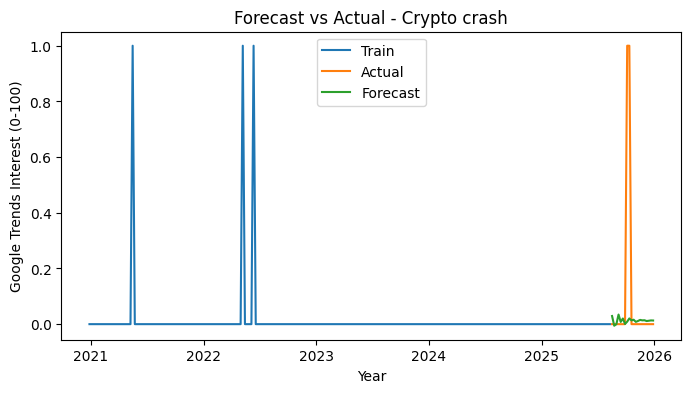

In [45]:
import matplotlib.pyplot as plt

for col in data.columns:

    plt.figure(figsize=(8,4))

    plt.plot(train[col], label='Train')
    plt.plot(test[col], label='Actual')
    plt.plot(forecast_df[col], label='Forecast')

    plt.title(f'Forecast vs Actual - {col}')
    plt.xlabel('Year')
    plt.ylabel('Google Trends Interest (0-100)')
    plt.legend()

    plt.show()

### 13.5 VAR Forecast Result 
- The VAR model was used to generate forecasts for both Bitcoin and “crypto crash” over the out-of-sample period.
- As we can see that for Bitcoin, forecasted values follow the general level and direction of the actual data, indicating that the model is able to capture the overall trend reasonably well but the model does not fully reflect sudden spikes, suggesting that it smooths out short-term volatility.
- The forecasts for “crypto crash” remain close to zero, reflecting the dominant pattern of the series, which consists mostly of low or zero values. While the model captures this baseline behavior effectively, it fails to predict sudden spikes observed in the actual data.
- Overall, the VAR model performs reasonably well for smoother time series like Bitcoin, but its performance is limited when dealing with highly irregular and event-driven data such as “crypto crash”.


### 13.6 Forecast Accuracy Measure
RMSE is used to measure the accuracy of the VAR model forecasts. It calculates the average deviation between predicted and actual values, where a lower value indicates better performance.

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Compute MSE first
mse_bitcoin = mean_squared_error(test['Bitcoin'], forecast_df['Bitcoin'])
mse_crash = mean_squared_error(test['Crypto crash'], forecast_df['Crypto crash'])

# Convert to RMSE
rmse_bitcoin = np.sqrt(mse_bitcoin)
rmse_crash = np.sqrt(mse_crash)

print("RMSE Bitcoin:", rmse_bitcoin)
print("RMSE Crypto crash:", rmse_crash)

RMSE Bitcoin: 7.481414443085637
RMSE Crypto crash: 0.31191035202391143


### 13.7 Interpretation of Forecast Accuracy
- The forecasting performance of the VAR model was evaluated using the Root Mean Squared Error (RMSE).
- For Bitcoin, the RMSE value is approximately 7.53, indicating a moderate level of prediction error. This suggests that the model captures the overall trend reasonably well, although some deviations occur, particularly during periods of sudden fluctuations.
- For “crypto crash”, the RMSE value is relatively low (approximately 0.31). However, this low value reflects the fact that the series consists mostly of zero values, and the model predicts these baseline levels accurately. Despite this, the model fails to capture sudden spikes in the data.
- Overall, the VAR model provides reasonable accuracy for smoother series like Bitcoin but performs poorly in capturing rare and event-driven behavior such as “crypto crash” spikes.

## 14. SARIMA Models 
- In addition to the VAR model, a univariate time series approach is applied using the Box-Jenkins methodology. The SARIMA model is used to analyze each time series individually without considering interactions between variables.
- SARIMA models are useful for capturing patterns such as autocorrelation, seasonality, and persistence within a single time series.

### 14.1 SARIMA Model Selection using AIC and BIC

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

results = []

orders = [
    (1,0,0),
    (1,0,1),
    (2,0,0),
    (2,0,1),
    (1,1,1),
    (2,1,1)
]

for order in orders:
    try:
        model = SARIMAX(
            train['Bitcoin'],
            order=order,
            seasonal_order=(1,0,0,52)
        )

        fit = model.fit(disp=False)

        results.append([
            order,
            fit.aic,
            fit.bic
        ])

    except:
        pass

results_df = pd.DataFrame(
    results,
    columns=['Order','AIC','BIC']
)

results_df.sort_values('AIC')

c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python

,Order,AIC,BIC
4,"(2, 1, 1)",1719.736206,1737.160191
3,"(1, 1, 1)",1719.868350,1733.807538
2,"(2, 0, 1)",1732.302953,1749.747641
1,"(2, 0, 0)",1759.952044,1773.907794
0,"(1, 0, 0)",1763.799508,1774.266322


Several SARIMA model specifications were evaluated using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). Among the candidate models, SARIMA(2,1,1) produced the lowest AIC value (1720.60), indicating the best overall fit to the Bitcoin search data. Therefore, SARIMA(2,1,1) was selected as the preferred model for forecasting.

### 14.2 Plot ACF & PACF 

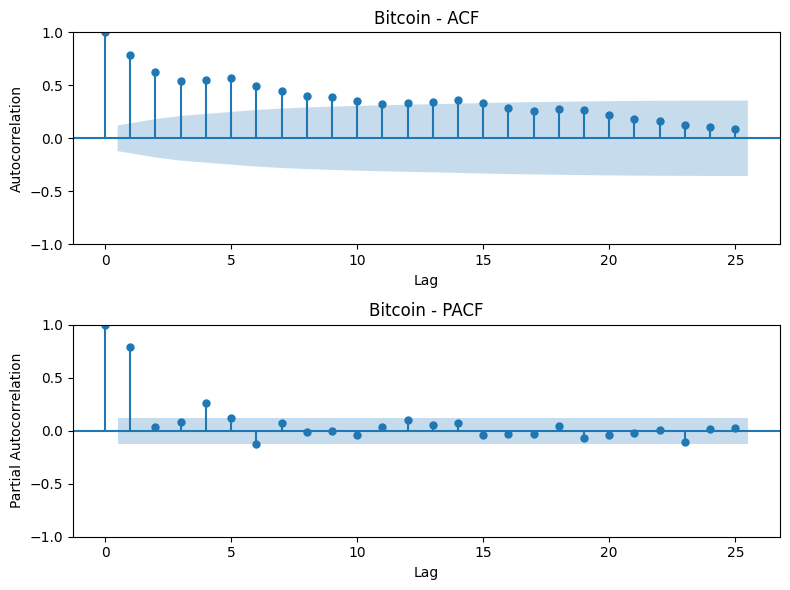

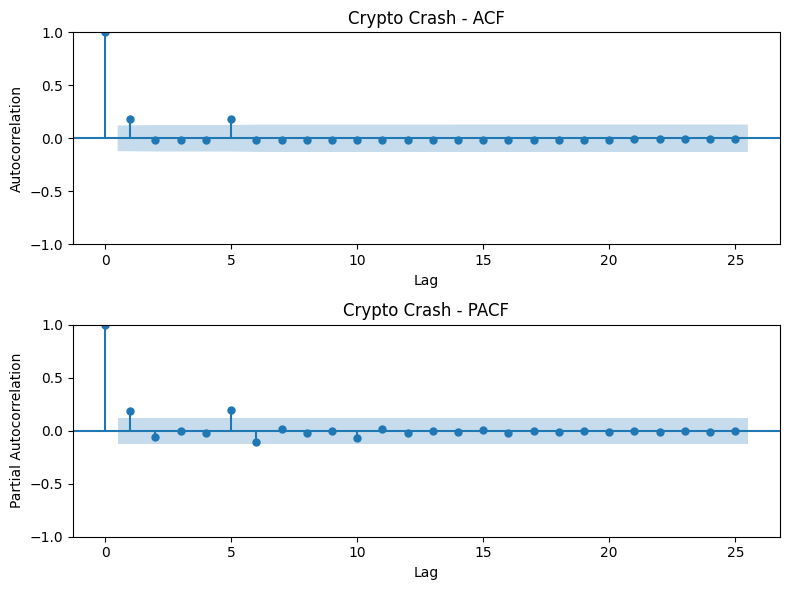

In [46]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -------- Bitcoin --------
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(data['Bitcoin'], ax=axes[0])
axes[0].set_title('Bitcoin - ACF')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(data['Bitcoin'], ax=axes[1])
axes[1].set_title('Bitcoin - PACF')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()


# -------- Crypto Crash --------
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(data['Crypto crash'], ax=axes[0])
axes[0].set_title('Crypto Crash - ACF')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

plot_pacf(data['Crypto crash'], ax=axes[1])
axes[1].set_title('Crypto Crash - PACF')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

### Identification using ACF and PACF
- The ACF and PACF plots were used to examine the dependence structure of both time series.
- For Bitcoin, the ACF declines gradually while the PACF shows a strong spike at lag 1 indicating significant persistence and suggesting an autoregressive component.
- For Crypto Crash both ACF and PACF display weak and irregular correlation, reflecting its event-driven and spike based behavior.
- These observations provide an initial guide for model specification, which is further refined using information criteria such as AIC and BIC.

## 15. SARIMA Model Estimation
- Based on the identification step, SARIMA models are estimated for both Bitcoin and “crypto crash”. The selected models are fitted to the data in order to capture the underlying time series structure and obtain parameter estimates.

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------- Bitcoin --------
model_btc = SARIMAX(
    data['Bitcoin'],
    order=(1,0,0),
    seasonal_order=(1,0,0,52)
)
result_btc = model_btc.fit()

# -------- Crypto crash --------
model_crash = SARIMAX(
    data['Crypto crash'],
    order=(1,0,0),
    seasonal_order=(0,0,0,52)
)
result_crash = model_crash.fit()

c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\getde\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [52]:
result_btc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Bitcoin   No. Observations:                  262
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 52)   Log Likelihood                -947.671
Date:                            Sun, 06 Sep 2026   AIC                           1901.342
Time:                                    00:06:38   BIC                           1912.047
Sample:                                12-27-2020   HQIC                          1905.644
                                     - 12-28-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9641      0.011     86.582      0.000       0.942       0.986
ar.S.L52       0.0430      0.064      0.668      0.504      -0.083       0.169
sigma2        80.2961      3.488     23.019      0.000      73.459      87.133
===================================================================================
Ljung-Box (L1) (Q):                   6.19   Jarque-Bera (JB):               478.66
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               0.29   Skew:                             1.10
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
result_crash.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           Crypto crash   No. Observations:                  262
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 152.182
Date:                Sun, 06 Sep 2026   AIC                           -300.364
Time:                        00:06:41   BIC                           -293.228
Sample:                    12-27-2020   HQIC                          -297.496
                         - 12-28-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1992      0.021      9.396      0.000       0.158       0.241
sigma2         0.0183      0.000     54.855      0.000       0.018       0.019
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             24475.56
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                             6.69
Prob(H) (two-sided):                  0.00   Kurtosis:                        48.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 15.1 Interpretation of SARIMAX Result
- For Bitcoin, the model captures the strong persistence in the data, although some autocorrelation remains in the residuals, indicating that the model does not fully account for all underlying dynamics. 
- For “crypto crash”, the model performs better in terms of residual diagnostics, as it shows no significant autocorrelation. However, it fails to capture sudden spikes, reflecting the irregular and event-driven nature of the series.
- Overall, the results highlight that SARIMA models can effectively capture general patterns in the data, but may struggle with complex dynamics and rare extreme events.

### 15.2 SARIMA Residual Analysis

In [54]:
btc_residuals = result_btc.resid

In [55]:
crash_residuals = result_crash.resid

### 15.3 ACF and PACF of Residuals

<Figure size 800x400 with 0 Axes>

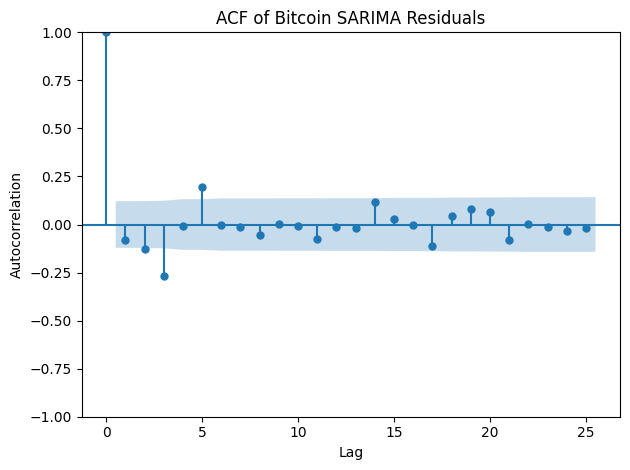

<Figure size 800x400 with 0 Axes>

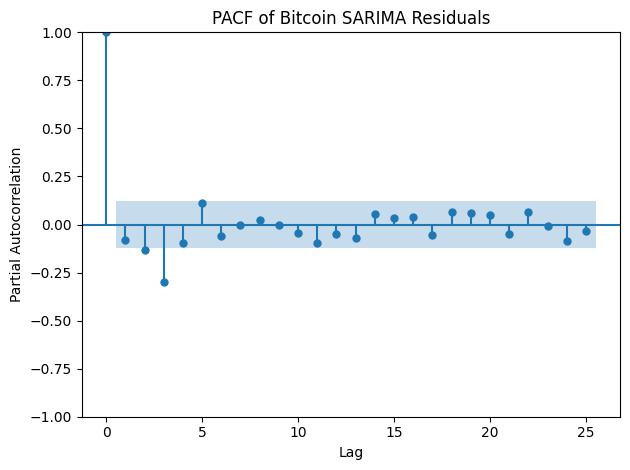

In [56]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF Plot
plt.figure(figsize=(8,4))
plot_acf(btc_residuals, lags=25)
plt.title("ACF of Bitcoin SARIMA Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# PACF Plot
plt.figure(figsize=(8,4))
plot_pacf(btc_residuals, lags=25, method='ywm')
plt.title("PACF of Bitcoin SARIMA Residuals")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

Most Residual autocorrelation fall within the confidence intervals, indicating little remaining structure in the residuals.
This suggests that SARIMA model captures the main patterns of the Bitcoin series effectively.
Overall, the residuals resemble white noise, supporting the adequecy of the fitted model.

<Figure size 800x400 with 0 Axes>

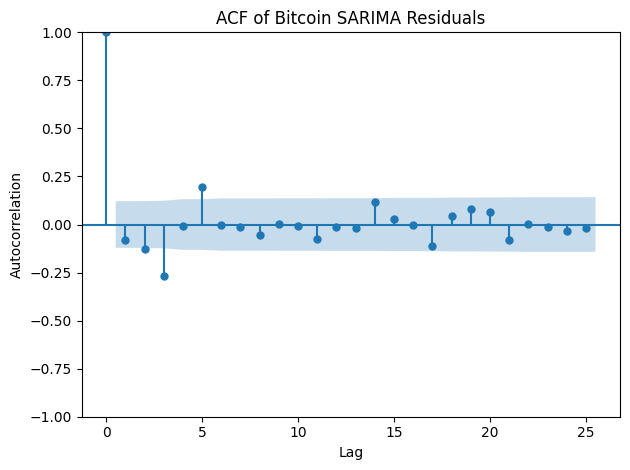

<Figure size 800x400 with 0 Axes>

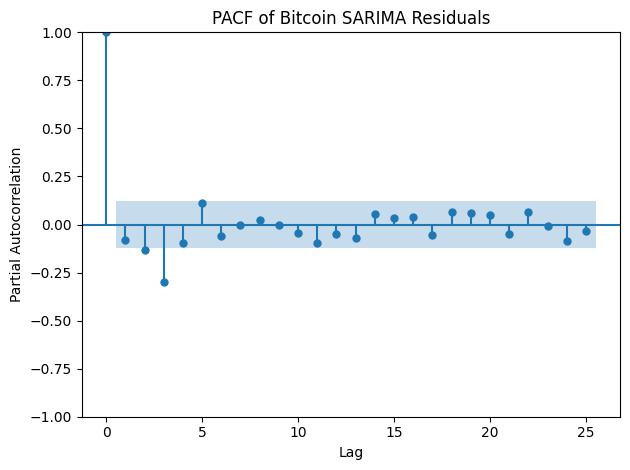

In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF Plot
plt.figure(figsize=(8,4))
plot_acf(btc_residuals,lags=25)
plt.title("ACF of Bitcoin SARIMA Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# PACF Plot
plt.figure(figsize=(8,4))
plot_pacf(btc_residuals, lags=25, method='ywm')
plt.title("PACF of Bitcoin SARIMA Residuals")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

Most residual autocorrelation fall within the confidence intervals, indicating little remaining structure in the residuals.
The SARIMA model successfully captures the main dynamics of the Crypto Crash series.
Overall, the residuals resemble white noise, supporting the adequacy of the fitted model.

In [58]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_btc = acorr_ljungbox(btc_residuals, lags=[10], return_df=True)
lb_crash = acorr_ljungbox(crash_residuals, lags=[10], return_df=True)

print("Bitcoin Residuals")
print(lb_btc)

print("\nCrypto Crash Residuals")
print(lb_crash)

Bitcoin Residuals
      lb_stat  lb_pvalue
10  36.162818   0.000079

Crypto Crash Residuals
      lb_stat  lb_pvalue
10  14.137914   0.166793


### 15.4 Interpretation of Ljung-Box Test
The Ljung-Box test suggests that the Bitcoin residuals still contain significant autocorrelation (p < 0.05), indicating that the model does not fully capture all patterns in the series. In contrast, the Crypto Crash residuals show no significant autocorrelation (p > 0.05), suggesting that the model has adequately captured the information contained in the data and that the residuals behave like white noise.

## 16. SARIMA Forecasting
The SARIMA models are used to generate forecasts for both Bitcoin and “crypto crash” over the out-of-sample period. These forecasts allow us to evaluate how well the models capture the individual behavior of each series.

In [59]:
btc_forecast = result_btc.forecast(steps=20)
crash_forecast = result_crash.forecast(steps=20)

### 16.1 Forecast vs Actual

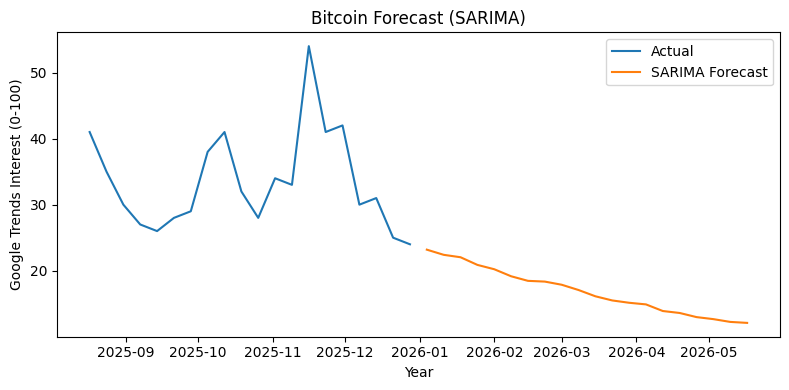

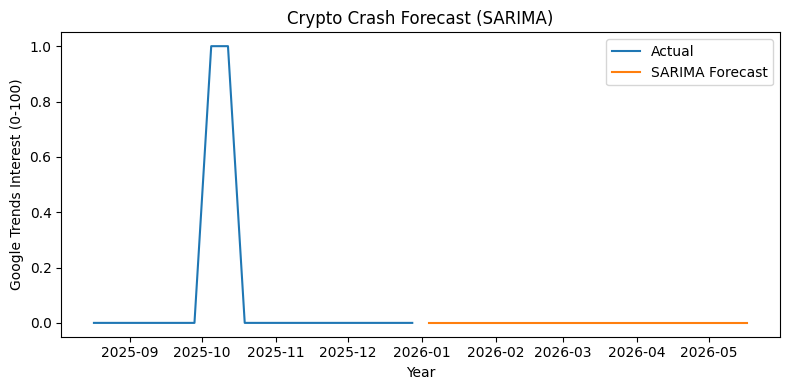

In [62]:
import matplotlib.pyplot as plt

# Bitcoin
plt.figure(figsize=(8,4))
plt.plot(test['Bitcoin'], label='Actual')
plt.plot(btc_forecast, label='SARIMA Forecast')
plt.title('Bitcoin Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Google Trends Interest (0-100)')
plt.legend()
plt.tight_layout()
plt.show()

# Crypto crash
plt.figure(figsize=(8,4))
plt.plot(test['Crypto crash'], label='Actual')
plt.plot(crash_forecast, label='SARIMA Forecast')
plt.title('Crypto Crash Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Google Trends Interest (0-100)')
plt.legend()
plt.tight_layout()
plt.show()

The SARIMA forecasts suggest that Bitcoin search interest may gradually decrease over time, while searches related to Crypto crashes are expected to remain low. The model captures the overall trend reasonably well but struggles to predict sudden spikes or unexpected market events, which are common in cryptocurrency related search behavior.

### 16.2 RMSE for SARIMA

In [63]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_btc_sarima = np.sqrt(mean_squared_error(test['Bitcoin'], btc_forecast))
rmse_crash_sarima = np.sqrt(mean_squared_error(test['Crypto crash'], crash_forecast))

print("SARIMA RMSE Bitcoin:", rmse_btc_sarima)
print("SARIMA RMSE Crypto crash:", rmse_crash_sarima)

SARIMA RMSE Bitcoin: 18.36477366946327
SARIMA RMSE Crypto crash: 0.31622776601683794


### 16.3 Forecast Accuracy (SARIMA)
- The forecasting performance of the SARIMA model was evaluated using the Root Mean Squared Error (RMSE).
- For Bitcoin, the RMSE value is relatively high (18.44), indicating that the model has a larger prediction error. This suggests that SARIMA does not perform well for Bitcoin, as it struggles to capture its volatility and sudden fluctuations.
- For “crypto crash”, the RMSE value is low (approximately 0.32). However, this result is somewhat misleading because the series mostly contains zero values, and the model simply predicts this baseline pattern. Despite the low error, the model fails to capture sudden spikes.
- Overall, the SARIMA model performs poorly for Bitcoin and provides only a basic representation for “crypto crash”, highlighting its limitations in handling volatile and spike-driven data.


## 17. Comparison of VAR and SARIMA Model
- Both VAR and SARIMA models were applied to forecast Google Trends data for "Bitcoin" and "Crypto Crash". The VAR model considers the interaction between multiple variables while SARIMA models each series independently.
- The forecasting results show that the VAR model achieved a lower RMSE for Bitcoin compared to SARIMA indicating better predictive performance. This suggests that information contained in "Crypto Crash" searches helps explain future movements in Bitcoin search interest.
- SARIMA was able to capture the general trend of each series but struggled to model sudden fluctuations and spikes particularly in the Bitcoin series. In contrast, VAR benefited from the dynamic relationship between the two variables and produced more accurate forecasts.
- Overall, the VAR model outperformed SARIMA for this dataset and is therefore the preferred forecasting approach for analyzing the relationship between Bitcoin and Crypto market sentiment.

## 18. Final Conclusion
- This study compared VAR and SARIMA models using Google Trends data for "Bitcoin" and "Crypto Crash" from 2021 to 2025. Both models were able to capture the overall behavior of the series; however, the VAR model produced more accurate forecasts as evidenced by its lower RMSE values.
- The results indicate that Bitcoin search activity is influenced not only by its own past values but also by changes in crypto crash-related searches. Because VAR incorporates these interactions, it provides a more comprehensive representation of the data.
- The VAR model outperformed the SARIMA model based on forecast accuracy and lower RMSE values. Since VAR incorporates information from both Bitcoin and Crypto Crash search activity, it was better able to capture the dynamics of the dataset.
- Therefore, for this dataset, the VAR model is considered more effective than SARIMA and is recommended for forecasting cryptocurrency-related search trends.

### 18.1 Limitations
- This study has some limitations. Google Trends data measures public interest rather than actual market performance. In addition only two keywords were analyzed, while many other factors can affect cryptocurrency sentiment.
- Finally, unexpected market events and sudden changes in investor behavior may reduce the accuracy of the forecasts. 